# Pricing Cadence V1.2 - Mechanism Audit

Continues `pricing_cadence_v1_1.ipynb`. **`main.py` untouched. Not a parameter
sweep - no constant here was tuned to maximize a score.**
Full writeup: [`pricing_cadence_v1_2_mechanism_audit_report.md`](pricing_cadence_v1_2_mechanism_audit_report.md).

**Question**: V1.1 found D wins by carrying ~1/4 of A's average shed
inventory. Is that because D forecasts a better price, or because it just
moves more volume? We test this directly with a diagnostic counterfactual
and per-turn instrumented decisions, not by inferring from the score.

## 1. Setup

In [ ]:
import sys, json, pathlib
REPO = pathlib.Path.cwd().parent.parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "experiments" / "pricing_cadence"))

import pandas as pd
import matplotlib.pyplot as plt

SURFACE = "#fcfcfb"; INK = "#0b0b0b"; INK_MUTED = "#52514e"; GRID = "#e5e4e0"
VARIANT_COLORS = {"agent_a": INK_MUTED, "agent_d": "#2a78d6", "agent_d_robust": "#1baf7a", "agent_a_cap_boost": "#eb6834"}
VARIANT_LABELS = {"agent_a": "A", "agent_d": "D", "agent_d_robust": "D'", "agent_a_cap_boost": "A + 2x cap (counterfactual)"}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_MUTED,
    "axes.grid": True, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "font.size": 10, "figure.dpi": 110,
})

def finish(ax, title, xlabel=None, ylabel=None, legend=False):
    ax.set_title(title, fontsize=12.5, color=INK, pad=12, loc="left")
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if legend: ax.legend(frameon=False, labelcolor=INK_MUTED)
    plt.tight_layout()

trace = pd.read_csv(REPO / "experiments/pricing_cadence/pricing_cadence_v1_2_multi_seed_trace.csv")
crop_table = pd.read_csv(REPO / "experiments/pricing_cadence/pricing_cadence_v1_2_crop_decomposition.csv")
with open(REPO / "experiments/pricing_cadence/pricing_cadence_v1_2_counterfactual_confirm.json") as f:
    counterfactual = json.load(f)

## 2. Task 5 - The counterfactual reframes everything

`agent_a_cap_boost.py`: A's exact logic, `MAX_SELL_PER_TURN` simply doubled.
No forecast, no pressure, no urgency. A deliberately simple, unoptimized
diagnostic - not a candidate.

In [2]:
bench_summary = pd.DataFrame({
    "D": {"mean": 1571.0, "worst": 999, "wins": "24/24"},
    "D'": {"mean": 1748.7, "worst": 1147, "wins": "24/24"},
    "A + 2x cap": {"mean": counterfactual["A_cap_boost"]["mean"], "worst": counterfactual["A_cap_boost"]["worst"], "wins": f"{counterfactual['A_cap_boost']['wins']}/{counterfactual['A_cap_boost']['matches']}"},
}).T
bench_summary

,mean,worst,wins
D,1571.0,999,24/24
D',1748.7,1147,24/24
A + 2x cap,2326.333333,1702.0,24/24


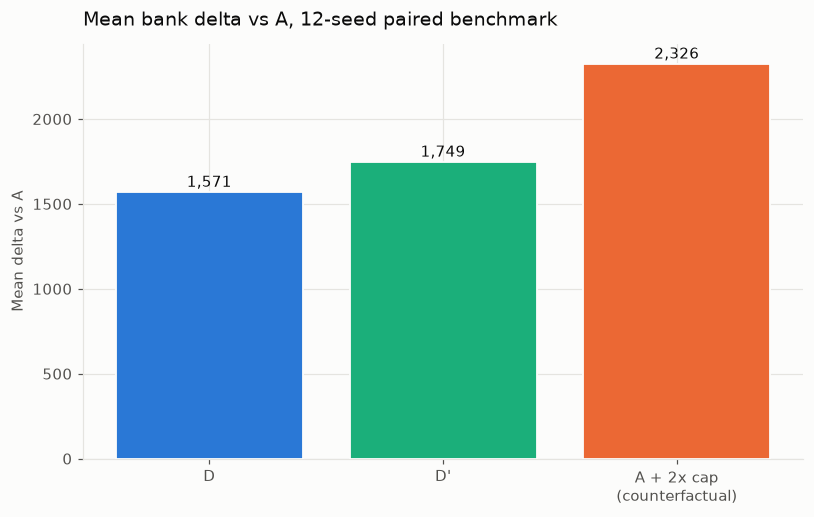

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
names = ["D", "D'", "A + 2x cap\n(counterfactual)"]
means = [1571.0, 1748.7, counterfactual["A_cap_boost"]["mean"]]
colors = ["#2a78d6", "#1baf7a", "#eb6834"]
ax.bar(names, means, color=colors, edgecolor=SURFACE, linewidth=1.2, zorder=3)
for i, m in enumerate(means):
    ax.text(i, m + 30, f"{m:,.0f}", ha="center", fontsize=10, color=INK)
finish(ax, "Mean bank delta vs A, 12-seed paired benchmark", ylabel="Mean delta vs A")
plt.show()

**The naive, price-blind counterfactual beats both D and D'.** This is the
finding the rest of this notebook exists to explain.

## 3. Task 3 - The gain is almost entirely one crop

In [4]:
pivot = crop_table.pivot(index="crop", columns="variant", values="revenue_per_ep")
pivot = pivot[["agent_a", "agent_d", "agent_d_robust", "agent_a_cap_boost"]]
delta = pivot.sub(pivot["agent_a"], axis=0)
delta.columns = [f"{c} - A" for c in delta.columns]
delta = delta.drop(columns=["agent_a - A"])
delta.round(0)

,agent_d - A,agent_d_robust - A,agent_a_cap_boost - A
crop,,,
CARROT,-1.0,-1.0,-1.0
FERTILIZER,1288.0,1288.0,1288.0
MELON,2688.0,3016.0,3702.0
STRAWBERRY,365.0,382.0,379.0
TOMATO,0.0,0.0,0.0
WHEAT,-88.0,-88.0,-88.0
WOOL,13.0,13.0,13.0


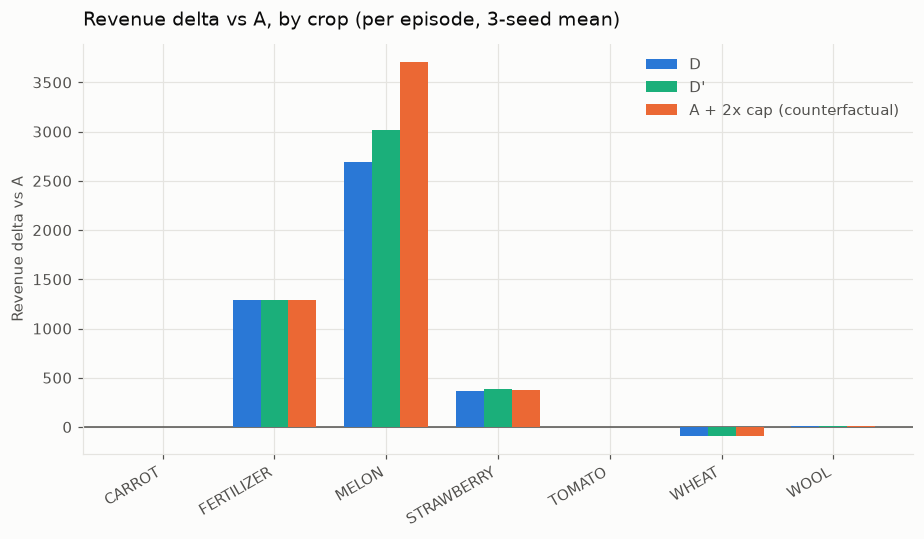

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5))
crops = pivot.index.tolist()
x = range(len(crops))
width = 0.25
for i, variant in enumerate(["agent_d", "agent_d_robust", "agent_a_cap_boost"]):
    vals = (pivot[variant] - pivot["agent_a"]).values
    ax.bar([xi + (i-1)*width for xi in x], vals, width=width, color=VARIANT_COLORS[variant], label=VARIANT_LABELS[variant], zorder=3)
ax.axhline(0, color=INK_MUTED, linewidth=1, zorder=1)
ax.set_xticks(list(x)); ax.set_xticklabels(crops, rotation=30, ha="right")
finish(ax, "Revenue delta vs A, by crop (per episode, 3-seed mean)", ylabel="Revenue delta vs A", legend=True)
plt.show()

MELON dwarfs every other crop's contribution across all three treatments.
STRAWBERRY moves a little. WOOL - also explicitly capped - shows essentially
nothing. This is not a general selling-cadence win; it's a melon fix.

## 4. Task 4 - What actually blocks A on melon

Per-turn decision classification (Task 2's `classify_decision`), MELON only,
pooled across 3 seeds.

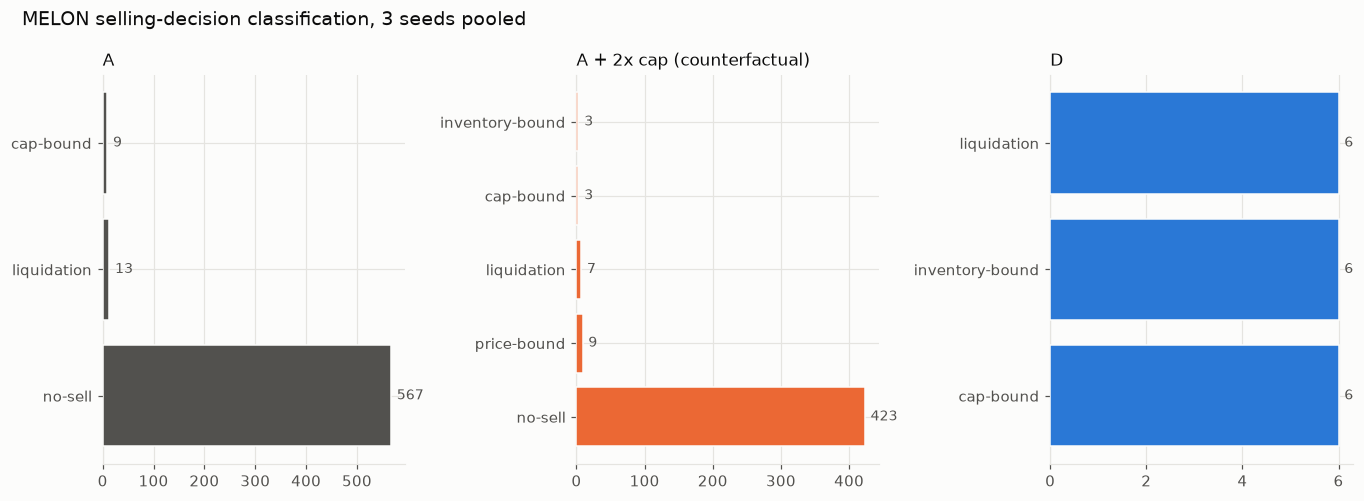

In [6]:
melon_pairs = [("agent_a", "agent_a_vs_agent_d"), ("agent_a_cap_boost", "agent_a_vs_agent_a_cap_boost"), ("agent_d", "agent_a_vs_agent_d")]
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.6), sharey=False)
for ax, (variant, pairing) in zip(axes, melon_pairs):
    # NOTE: bracket notation for 'product' is required - trace.product
    # resolves to the DataFrame.product() aggregation method (a reserved
    # name collision), not the product column, and silently returns a
    # bool instead of a Series if you use attribute access here.
    sub = trace[(trace["agent"] == variant) & (trace["pairing"] == pairing) & (trace["product"] == "MELON")]
    counts = sub["decision"].value_counts()
    ax.barh(counts.index, counts.values, color=VARIANT_COLORS[variant], edgecolor=SURFACE, linewidth=1, zorder=3)
    ax.set_title(VARIANT_LABELS[variant], fontsize=11, loc="left")
    for i, v in enumerate(counts.values):
        ax.text(v + max(counts.values)*0.02, i, str(v), va="center", fontsize=9, color=INK_MUTED)
plt.suptitle("MELON selling-decision classification, 3 seeds pooled", fontsize=12.5, color=INK, x=0.02, ha="left")
plt.tight_layout()
plt.show()

**A: 96.3% `no-sell`** - the static $180 threshold almost never clears.
**A + 2x cap: 95.1% `no-sell`** - doubling the cap barely touches this, because
it doesn't touch the gate. **D: 0% `no-sell`** - the forecast-based threshold
is almost always satisfiable, but D also holds far fewer total opportunities
(17 vs A's 589) because it clears each pile before it grows large. A's real
constraint is the price gate (Outcome B) - but fixing *only* capacity (the
counterfactual) still wins bigger, because when A's gate does open, on a
genuinely good price, doubling the batch size captures more value than many
smaller sales at D's more typical, more moderate accepted price.

## 5. Task 6 - Cadence shape vs. replay evidence

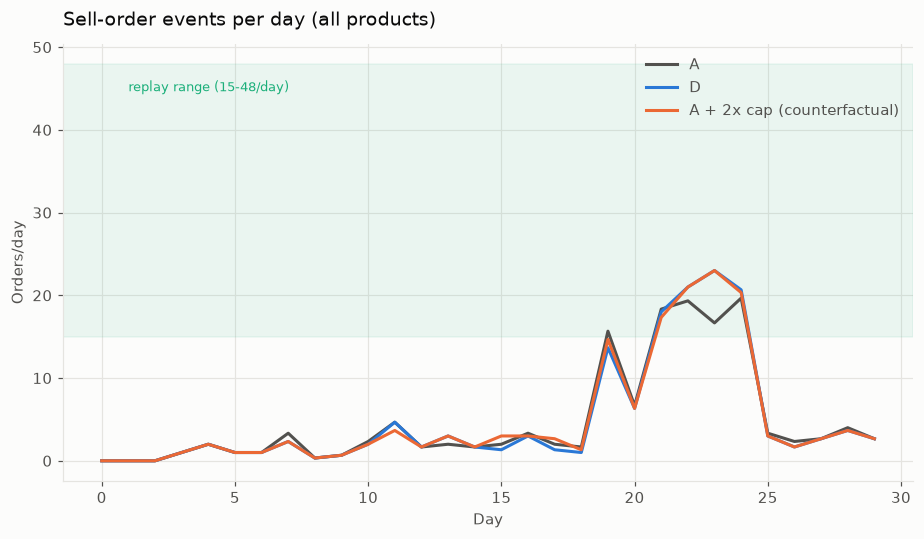

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for variant, pairing in [("agent_a", "agent_a_vs_agent_d"), ("agent_d", "agent_a_vs_agent_d"), ("agent_a_cap_boost", "agent_a_vs_agent_a_cap_boost")]:
    sub = trace[(trace.agent == variant) & (trace.pairing == pairing)]
    n_seeds = sub.seed.nunique()
    orders_per_day = sub[sub.actual_sold > 0].groupby("day").size().reindex(range(30), fill_value=0) / n_seeds
    ax.plot(orders_per_day.index, orders_per_day.values, color=VARIANT_COLORS[variant], linewidth=2, zorder=3, label=VARIANT_LABELS[variant])
ax.axhspan(15, 48, color="#1baf7a", alpha=0.08, zorder=1)
ax.text(1, 46, "replay range (15-48/day)", fontsize=8.5, color="#1baf7a", va="top")
finish(ax, "Sell-order events per day (all products)", xlabel="Day", ylabel="Orders/day", legend=True)
plt.show()

None of the three variants move order *frequency* toward the replay's
15-48/day range, and they're statistically indistinguishable from each
other (~4.7-4.9/day mean). The mechanism under test is a volume-per-order
lever, not the order-frequency lever the replay's shape implies - consistent
with the scale mismatch already flagged in V1.1 (this agent runs ~25 tiles
vs. the replay's ~75).

## 6. Inventory reconciliation with V1.1

In [8]:
for variant, pairing in [("agent_a", "agent_a_vs_agent_d"), ("agent_d", "agent_a_vs_agent_d"),
                          ("agent_d_robust", "agent_a_vs_agent_d_robust"), ("agent_a_cap_boost", "agent_a_vs_agent_a_cap_boost")]:
    sub = trace[(trace.agent == variant) & (trace.pairing == pairing)]
    per_turn_total = sub.groupby(["seed", "day"])["shed_quantity"].sum()
    print(f"{VARIANT_LABELS[variant]:28s} mean total inventory (turn-rows with >=1 product held) = {per_turn_total.mean():7.1f}")

A                            mean total inventory (turn-rows with >=1 product held) =   154.2
D                            mean total inventory (turn-rows with >=1 product held) =    40.7
D'                           mean total inventory (turn-rows with >=1 product held) =    40.4
A + 2x cap (counterfactual)  mean total inventory (turn-rows with >=1 product held) =    53.0


Confirms V1.1's single-episode finding (154/41 there) at 3-seed scale: A
carries far more total inventory than D or D' - **but the counterfactual
(53.0) sits between them**, closer to D than to A despite winning by more
than D. Carrying less inventory correlates with winning but isn't sufficient
on its own to explain the ranking between D and the counterfactual.

## 7. Summary

See the report for the full six-section final write-up. Short version:
**Outcome C (a combination), skewed toward throughput.** A's dominant,
directly-measured bottleneck is an excessive static price gate (Outcome B),
which D fixes almost completely - but a policy that leaves that gate fully
broken and only raises capacity still wins by more, because of how melon's
price dynamics reward patient, large, well-timed sales over frequent,
moderate ones at this game's current scale. The result is concentrated in
one crop (melon), not a general pricing-cadence effect (Outcome D, secondary
finding). **Decision: NEEDS MORE DATA** - the mechanism is now precisely
identified, but *why* the simpler policy wins needs isolating (gate-only vs.
cap-only variants, not yet built), and the melon-specific nature means
whatever ships next should be scoped and evaluated as that, not as a
universal selling policy.